In [ ]:
# Nama Lengkap: Khairil Ramadhani
# NIM: 240401040511
# Kelas: IF405

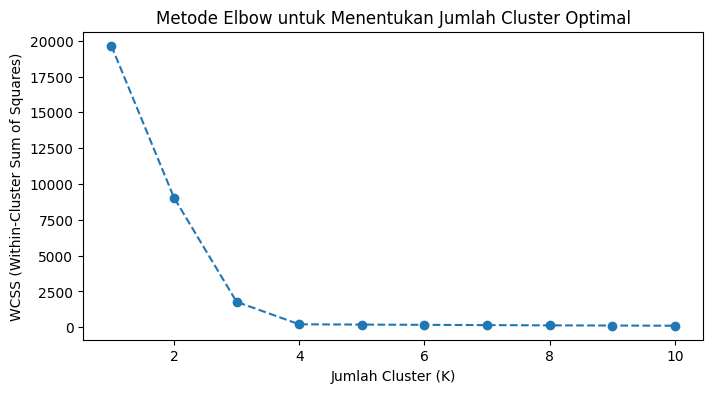

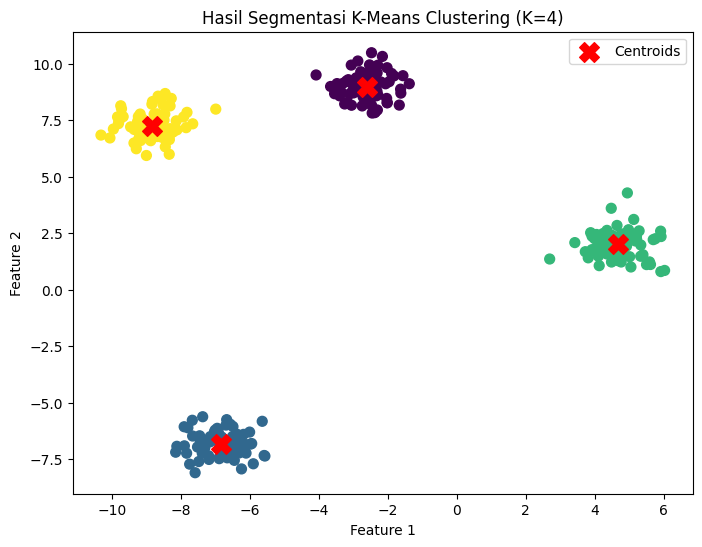

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Membuat data dummy untuk proses clustering
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)
X_df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])

# Menghitung WCSS untuk berbagai jumlah cluster (Metode Elbow)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_df)
    wcss.append(kmeans.inertia_)

# Visualisasi Metode Elbow
plt.figure(figsize=(8,4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Metode Elbow untuk Menentukan Jumlah Cluster Optimal')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.show()

# Implementasi K-Means dengan K optimal (misal K=4)
kmeans_final = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
y_kmeans = kmeans_final.fit_predict(X_df)

# Visualisasi Hasil Cluster dan Titik Centroid
plt.figure(figsize=(8,6))
plt.scatter(X_df.iloc[:, 0], X_df.iloc[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans_final.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.title('Hasil Segmentasi K-Means Clustering (K=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

### Kesimpulan
- **Apa yang dipelajari:** Memahami konsep *Unsupervised Learning* khususnya klasterisasi data menggunakan algoritma K-Means dan teknik penentuan jumlah klaster optimal (*K*) menggunakan **Metode Elbow** berdasarkan nilai WCSS.
- **Temuan utama:** Grafik *Elbow* memperlihatkan titik siku (*elbow point*) yang mengindikasikan jumlah klaster ideal di mana penurunan nilai WCSS mulai melambat secara signifikan.
- **Keterbatasan / Pertanyaan:** Algoritma K-Means mensyaratkan penentuan jumlah klaster (*K*) di awal secara manual dan sangat sensitif terhadap keberadaan data *outlier* serta penentuan titik pusat awal (*centroid initialization*).